# Valle nuevo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Tensorflow
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential,save_model,load_model
from keras.layers import Dense
from keras.layers import LSTM
from keras.callbacks import EarlyStopping
from keras.metrics import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import keras

#Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dropout, Input
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error

In [13]:
train_serie = pd.read_csv(
    "../../Datos/valle_nuevo_train.csv",
    index_col=0,
    parse_dates=True
)["Viajero"]

test_serie = pd.read_csv(
    "../../Datos/valle_nuevo_test.csv",
    index_col=0,
    parse_dates=True
)["Viajero"]

In [17]:
tf.random.set_seed(123)
np.random.seed(123)

def crear_secuencias(datos_escalados, ventana):
    X, y = [], []
    for i in range(len(datos_escalados) - ventana):
        X.append(datos_escalados[i:i+ventana, 0])
        y.append(datos_escalados[i+ventana, 0])
    return np.array(X), np.array(y)

def construir_modelo(ventana, capas_unidades, dropout, lr):
    modelo = Sequential()
    modelo.add(Input(shape=(ventana, 1)))
    for idx, unidades in enumerate(capas_unidades):
        return_seq = idx < len(capas_unidades) - 1
        modelo.add(LSTM(unidades, return_sequences=return_seq))
        modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    modelo.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return modelo

def evaluar_config(train_serie, ventana, capas_unidades, dropout, lr, batch_size, epochs=100):
    """Entrena con un split interno 80/20 (cronológico) y devuelve RMSE/MAE de validación."""
    valores = train_serie.values.reshape(-1,1).astype(float)

    corte = int(len(valores) * 0.8)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(valores[:corte])  # ajustar SOLO con la parte de entrenamiento real
    valores_esc = scaler.transform(valores)

    X, y = crear_secuencias(valores_esc, ventana)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    corte_secuencias = corte - ventana
    X_train, y_train = X[:corte_secuencias], y[:corte_secuencias]
    X_val, y_val = X[corte_secuencias:], y[corte_secuencias:]

    modelo = construir_modelo(ventana, capas_unidades, dropout, lr)
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
               epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)

    pred_val = scaler.inverse_transform(modelo.predict(X_val, verbose=0))
    real_val = scaler.inverse_transform(y_val.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(real_val, pred_val))
    mae = mean_absolute_error(real_val, pred_val)
    return rmse, mae

# --- Grid de evidencia: variamos ventana, unidades, capas, dropout y lr ---
grid = [
    {'nombre': 'A: ventana6_1capa32',  'ventana': 6,  'capas_unidades': [32],     'dropout': 0.1, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_1capa32',    'ventana': 12, 'capas_unidades': [32],     'dropout': 0.1, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'B: ventana12_1capa50', 'ventana': 12, 'capas_unidades': [50],     'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana6_2capas',      'ventana': 6,  'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_2capas',     'ventana': 12, 'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.001,  'batch_size': 8},
    {'nombre': 'ventana12_2capas_lrbajo', 'ventana': 12, 'capas_unidades': [64, 32], 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 16},
]

resultados = []
for cfg in grid:
    rmse, mae = evaluar_config(train_serie, cfg['ventana'], cfg['capas_unidades'],
                                cfg['dropout'], cfg['lr'], cfg['batch_size'])
    resultados.append({'Config': cfg['nombre'], 'RMSE_val': round(rmse, 2), 'MAE_val': round(mae, 2)})
    print(f"{cfg['nombre']:24s} | RMSE_val={rmse:9.2f} | MAE_val={mae:9.2f}")

df_resultados = pd.DataFrame(resultados).sort_values('RMSE_val')
print("\nRanking (menor RMSE de validación = mejor):")
print(df_resultados.to_string(index=False))

A: ventana6_1capa32      | RMSE_val= 21932.34 | MAE_val= 15908.14
ventana12_1capa32        | RMSE_val= 23399.66 | MAE_val= 16469.72
B: ventana12_1capa50     | RMSE_val= 22758.73 | MAE_val= 16143.19
ventana6_2capas          | RMSE_val= 22832.53 | MAE_val= 16255.84
ventana12_2capas         | RMSE_val= 24281.58 | MAE_val= 18447.67
ventana12_2capas_lrbajo  | RMSE_val= 33250.84 | MAE_val= 26361.54

Ranking (menor RMSE de validación = mejor):
                 Config  RMSE_val  MAE_val
    A: ventana6_1capa32  21932.34 15908.14
   B: ventana12_1capa50  22758.73 16143.19
        ventana6_2capas  22832.53 16255.84
      ventana12_1capa32  23399.66 16469.72
       ventana12_2capas  24281.58 18447.67
ventana12_2capas_lrbajo  33250.84 26361.54


In [19]:
# Convertir a numpy
train_valores = train_serie.values.reshape(-1, 1)
test_valores = test_serie.values.reshape(-1, 1)

# Escalar usando SOLO el entrenamiento
scaler = MinMaxScaler(feature_range=(0, 1))
train_escalado = scaler.fit_transform(train_valores)
test_escalado = scaler.transform(test_valores)

## LSTM 1

In [22]:
ventana = 6 

X_train, y_train = crear_secuencias(train_escalado, ventana)
X_test, y_test = crear_secuencias(test_escalado, ventana)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [24]:
paso = 6              # ventana
caracteristicas = 1   # serie univariada
unidades = 32         # neuronas de la LSTM

inputs = keras.layers.Input(shape=(paso, caracteristicas))
lstm_out = keras.layers.LSTM(unidades)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

modelo1 = keras.Model(inputs=inputs, outputs=outputs)

modelo1.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 6, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
epocas = 100        # puedes dejar 100 porque usarás EarlyStopping
batch_size = 8      # según el mejor modelo

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = modelo1.fit(
    X_train,
    y_train,
    batch_size=8,
    epochs=100,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.3717 - root_mean_squared_error: 1.1712 - val_loss: 0.5756 - val_root_mean_squared_error: 0.7587
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1722 - root_mean_squared_error: 0.4149 - val_loss: 0.2313 - val_root_mean_squared_error: 0.4810
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0938 - root_mean_squared_error: 0.3062 - val_loss: 0.0706 - val_root_mean_squared_error: 0.2657
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0241 - root_mean_squared_error: 0.1551 - val_loss: 0.0803 - val_root_mean_squared_error: 0.2834
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0220 - root_mean_squared_error: 0.1482 - val_loss: 0.0734 - val_root_mean_squared_error: 0.2710
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0202 - root_mean_squared_error: 0.1423 - val_loss: 0.0654 - val_root_mean_squared_error: 0.2557
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss

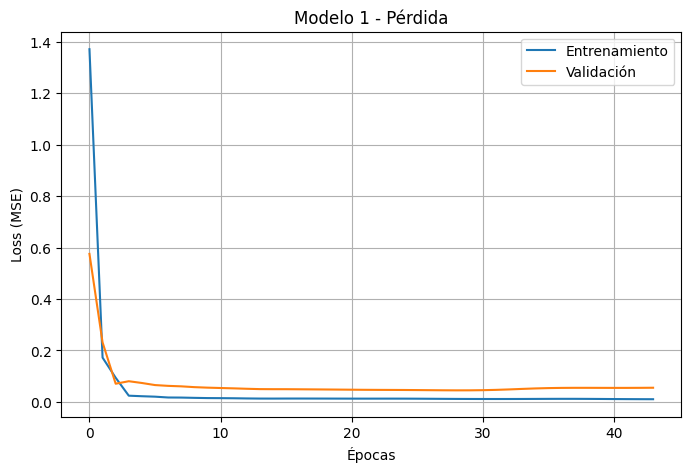

In [48]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')

plt.title('Modelo 1 - Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()

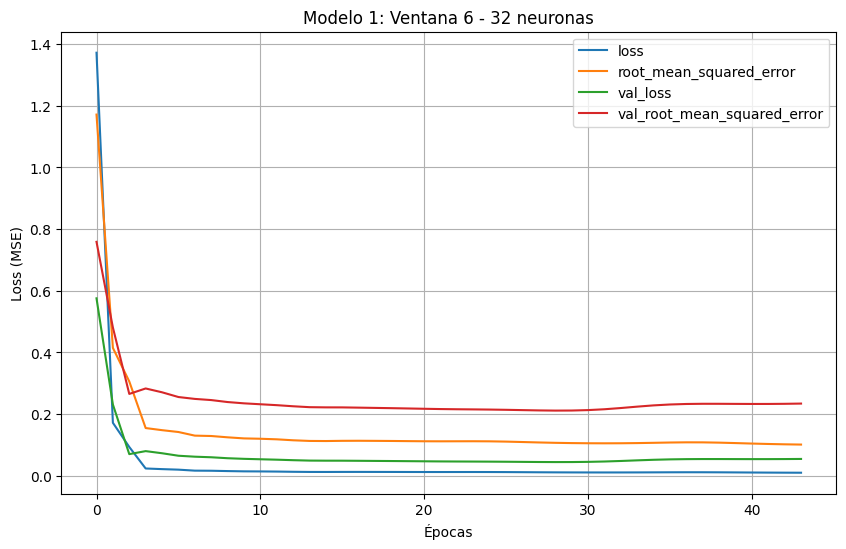

In [50]:
losses_df1 = pd.DataFrame(history.history)

losses_df1.plot(figsize=(10,6))

plt.title("Modelo 1: Ventana 6 - 32 neuronas")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

In [31]:
print("Pérdida en Entrenamiento")
modelo1.evaluate(
    x = X_train,
    y = y_train
)

print("Pérdida en Prueba")
modelo1.evaluate(
    x = X_test,
    y = y_test
)

Pérdida en Entrenamiento
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 - root_mean_squared_error: 0.1379 
Pérdida en Prueba
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0201 - root_mean_squared_error: 0.1417


[0.020066047087311745, 0.14165467023849487]

In [52]:
def prediccion_fun(data, modelo1, scaler):
    pred = modelo1.predict(data, verbose=0)
    pred = scaler.inverse_transform(pred)
    return pred.flatten()

In [53]:
print("X_test:", X_test.shape)
print("Modelo:", modelo1)

X_test: (51, 12, 1)
Modelo: <Functional name=functional_25, built=True>


In [54]:
prediccion_test = modelo1.predict(X_test, verbose=0)

# Regresar a la escala original
prediccion_test = scaler.inverse_transform(prediccion_test)

# Valores reales en la escala original
real_test = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

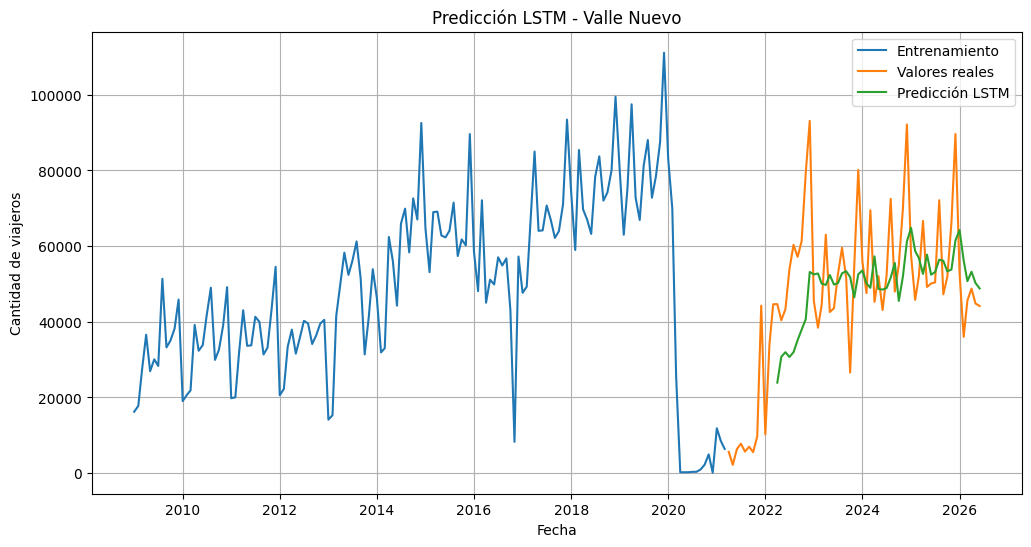

In [63]:
df_pred = pd.DataFrame(
    prediccion_test,
    index=test_serie.index[ventana:],
    columns=["Predicción"]
)

plt.figure(figsize=(12,6))

plt.plot(train_serie.index, train_serie.values, label="Entrenamiento")
plt.plot(test_serie.index, test_serie.values, label="Valores reales")
plt.plot(df_pred.index, df_pred["Predicción"], label="Predicción LSTM")

plt.title("Predicción LSTM - Valle Nuevo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
save_model(modelo1, "../../Modelos/lstm1_serie_tiempo.keras")

## LSTM 2

In [42]:
ventana = 12

X_train, y_train = crear_secuencias(train_escalado, ventana)
X_test, y_test = crear_secuencias(test_escalado, ventana)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [43]:
paso = 12
caracteristicas = 1
unidades = 50

inputs = keras.layers.Input(shape=(paso, caracteristicas))

x = keras.layers.LSTM(unidades)(inputs)
x = keras.layers.Dropout(0.2)(x)

outputs = keras.layers.Dense(1)(x)

modelo2 = keras.Model(inputs, outputs)

modelo2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

modelo2.summary()

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
epocas = 100
batch_size = 8

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history2 = modelo2.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epocas,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.6497 - root_mean_squared_error: 1.9104 - val_loss: 0.1712 - val_root_mean_squared_error: 0.4137
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2460 - root_mean_squared_error: 0.4960 - val_loss: 0.1150 - val_root_mean_squared_error: 0.3391
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0752 - root_mean_squared_error: 0.2742 - val_loss: 0.1382 - val_root_mean_squared_error: 0.3718
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0850 - root_mean_squared_error: 0.2915 - val_loss: 0.1608 - val_root_mean_squared_error: 0.4010
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0684 - root_mean_squared_error: 0.2615 - val_loss: 0.2359 - val_root_mean_squared_error: 0.4857
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0973 - root_mean_squared_error: 0.3120 - val_loss: 0.3447 - val_root_mean_squared_error: 0.5871
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss

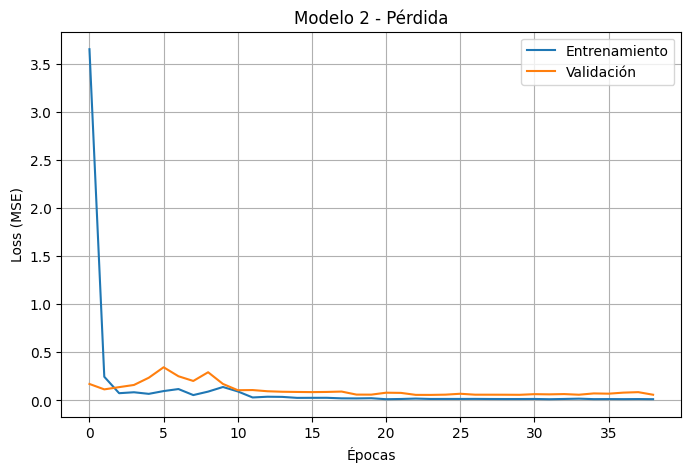

In [49]:
plt.figure(figsize=(8,5))

plt.plot(history2.history['loss'], label='Entrenamiento')
plt.plot(history2.history['val_loss'], label='Validación')

plt.title('Modelo 2 - Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()

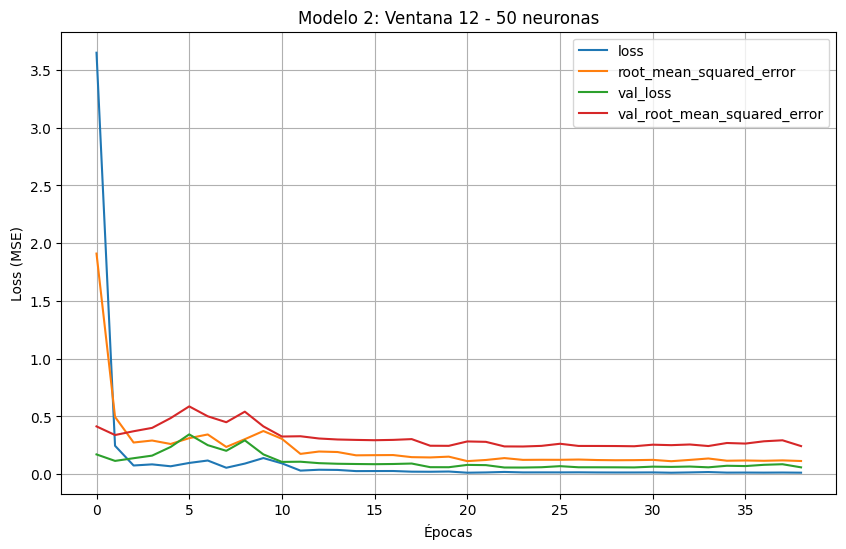

In [51]:
losses_df2 = pd.DataFrame(history2.history)

losses_df2.plot(figsize=(10,6))

plt.title("Modelo 2: Ventana 12 - 50 neuronas")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

In [56]:
print("Pérdida en Entrenamiento")
modelo2.evaluate(
    x = X_train,
    y = y_train
)

print("Pérdida en Prueba")
modelo2.evaluate(
    x = X_test,
    y = y_test
)

Pérdida en Entrenamiento
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0222 - root_mean_squared_error: 0.1491 
Pérdida en Prueba
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0209 - root_mean_squared_error: 0.1447


[0.02093394845724106, 0.14468568563461304]

In [57]:
def prediccion_fun(data, modelo2, scaler):
    pred = modelo2.predict(data, verbose=0)
    pred = scaler.inverse_transform(pred)
    return pred.flatten()

In [58]:
print("X_test:", X_test.shape)
print("Modelo:", modelo2)

X_test: (51, 12, 1)
Modelo: <Functional name=functional_28, built=True>


In [60]:
prediccion_test2 = modelo2.predict(X_test, verbose=0)

# Regresar a la escala original
prediccion_test2 = scaler.inverse_transform(prediccion_test2)

# Valores reales en la escala original
real_test = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

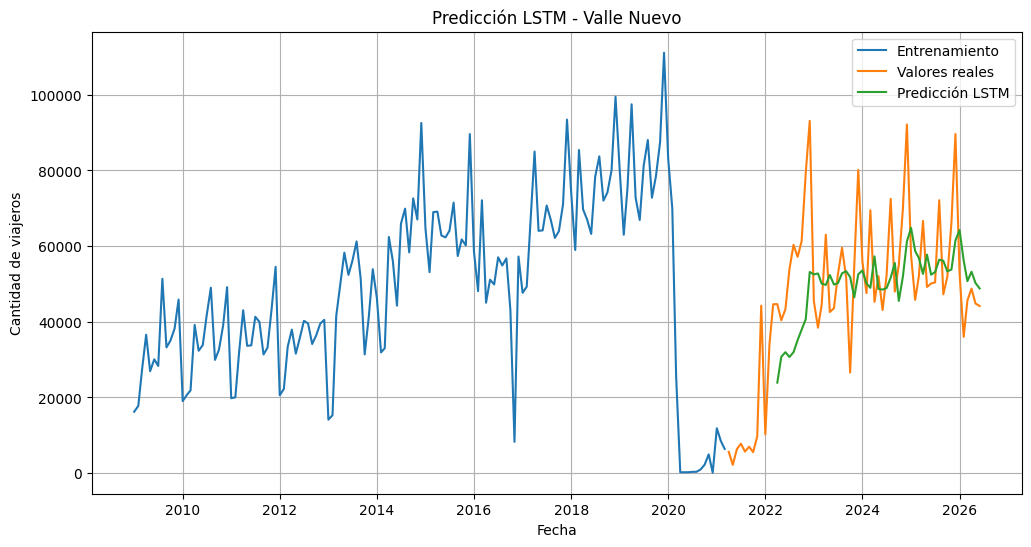

In [64]:
df_pred2 = pd.DataFrame(
    prediccion_test2,
    index=test_serie.index[ventana:],
    columns=["Predicción"]
)

plt.figure(figsize=(12,6))

plt.plot(train_serie.index, train_serie.values, label="Entrenamiento")
plt.plot(test_serie.index, test_serie.values, label="Valores reales")
plt.plot(df_pred2.index, df_pred2["Predicción"], label="Predicción LSTM")

plt.title("Predicción LSTM - Valle Nuevo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.grid(True)

plt.show()

In [62]:
save_model(modelo2, "../../Modelos/lstm2_serie_tiempo.keras")